# Full Reaction Network

\begin{align}
CO_2 + 3H_2 &\rightleftharpoons CH_3OH + H_2O\\
CO + 2H_2 &\rightleftharpoons CH_3OH\\
CO_2 + H_2 &\rightleftharpoons CO + H_2O\\
2CH_3OH &\rightleftharpoons CH_3OCH_3 + H_2O
\end{align}


# Yield

"How much of Educt i is converted into Product k"

\begin{equation}
    Y_{k} = \frac{\nu_i}{\nu_k} \, \frac{n_{k, 0}-n_{k}}{n_{i,0}}
\end{equation}

Educt is Methanol, everything else is a byproduct

# Reaction extend

\begin{equation}
    \xi_{i} = \frac{n_i - n_{i,0}}{\nu_i}
\end{equation}

# Importing the researched Glenn Data-Sets

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scp
import pandas as pd

# Pfad zu den Daten
data_path = r'c:\Users\Peter\Documents\Uni\Master\CRE 3\CRE3-Assignment-2\data_literature\NASA_shomate_coefficients_full.csv'

# NASA Glenn Koeffizienten laden
df_nasa = pd.read_csv(data_path)
print("\nGeladene Spezies:")
print(df_nasa[['species_name', 'formula', 'T1_min_K', 'T1_max_K', 'T2_min_K', 'T2_max_K']].to_string())


Geladene Spezies:
  species_name  formula  T1_min_K  T1_max_K  T2_min_K  T2_max_K
0           H2       H2     200.0    1000.0    1000.0    6000.0
1          H2O      H2O     200.0    1000.0    1000.0    6000.0
2           CO       CO     200.0    1000.0    1000.0    6000.0
3          CO2      CO2     200.0    1000.0    1000.0    6000.0
4        CH3OH    CH3OH     200.0    1000.0    1000.0    6000.0
5      CH3OCH3  CH3OCH3     200.0    1000.0    1000.0    6000.0


# Formulating the Matrix of stoichometric coefficients

\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
    & CO & CO_2 & CH_3OCH_3 & H_2 & H_2O & CH_3OH \\
R_1 & 0 & -1 & 0 & -3 & 1 & 1 \\
R_2 & -1 & 0 & 0 & -2 & 0 & 1 \\
R_3 & 1 & -1 & 0 & -1 & 1 & 0 \\
R_4 & 0 & 0 & 1 & 0 & 1 & -2
    \end{bmatrix}
\end{equation}

To ensure, that the mathematical method of the matrix of stochiometric coefficients is possible, we need to snure, that $N_{1,1}$ has an inverse matrix that can be calculated. A quick calculation shows, that R3 is equal to R1 -R2 ($R_1 - R_2 = R_3$). 

Therefor, R4 and R3 are interchanged, to enable a succesfull solution of the mathematical approach:

\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
    & CO & CO_2 & CH_3OCH_3 & H_2 & H_2O & CH_3OH \\
R_1 & 0 & -1 & 0 & -3 & 1 & 1 \\
R_2 & -1 & 0 & 0 & -2 & 0 & 1 \\
R_4 & 0 & 0 & 1 & 0 & 1 & -2  \\
R_3 & 1 & -1 & 0 & -1 & 1 & 0 
    \end{bmatrix}
\end{equation}

In [92]:
import numpy as np
from numpy.linalg import matrix_rank

# --- DME Synthesis Stoichiometric Analysis ---
# Component Order: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]
# Reaction Order adjusted: [R1, R2, R4, R3] to ensure N11 is non-singular
# This order ensures Key Components are in the first 3 rows (Rank = 3)

n_matrix = np.array([
    [ 0, -1,  0,  1],  # CO    
    [-1,  0,  0, -1],  # CO2   
    [ 0,  0,  1,  0],  # CH3OCH3 (DME) -> Now independent in the 3rd column (because R1-R2=R3)
    [-3, -2,  0, -1],  # H2    
    [ 1,  0,  1,  1],  # H2O   
    [ 1,  1, -2,  0]   # CH3OH
])

# Get the transposed matrix (N^T)
n_transposed = n_matrix.T

# Determine the rank of the matrix
n_rank = matrix_rank(n_matrix)

print("--- DME Synthesis Stoichiometric Analysis ---")
print(f"Sequence: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]")
print("\nTransposed Matrix (N^T):")
print(n_transposed)
print(f"\nMatrix Rank (Number of Key Reactions): {n_rank}")

# creating a list of species and their corresponding indexes in the transposed matrix/reactions 1-4
# Index 0 = R1, Index 1 = R2, Index 2 = R4, Index 3 = R3 (adjusted order for independence)
species = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']
reaction_tuples = np.full((len(n_transposed), len(species)), '', dtype=object)

for i in range(4):
    for j in range(len(species)):
        reaction_tuples[i][j] = (species[j], n_transposed[i][j])

--- DME Synthesis Stoichiometric Analysis ---
Sequence: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]

Transposed Matrix (N^T):
[[ 0 -1  0 -3  1  1]
 [-1  0  0 -2  0  1]
 [ 0  0  1  0  1 -2]
 [ 1 -1  0 -1  1  0]]

Matrix Rank (Number of Key Reactions): 3


The rank is $R_N=3$, which means that three key reactions and components are sufficient to describe the reaction extent based on stoichiometry. According to the order of components and reactions chosen for the matrix of stoichiometric coefficients, $CO$, $CO_2$, $CH_3OCH_3 (DME)$ are the key components. 

From this, we define the Matrices $N_{1,1}$, $N_{1,2}$, $N_{2,1}$ and $N_{2,2}$

In [93]:
# Defining the Matrizes N_{1,1}, N_{1,2}, N_{2,1} and N_{2,2}
N_11 = n_matrix[:3, :3]  # Key Reactions (R1, R2, R4) and Key Components (CO, CO2, CH3OCH3)
N_12 = n_matrix[:3, 3:]  # Key Reactions (R1, R2, R4) and Non-Key Components (H2, H2O, CH3OH)
N_21 = n_matrix[3:, :3]  # Non-Key Reactions (R3) and Key Components (CO, CO2, CH3OCH3)
N_22 = n_matrix[3:, 3:]  # Non-Key Reactions (R3) and Non-Key Components (H2, H2O, CH3OH)

print("\nN_11 (Key Reactions vs Key Components):")
print(N_11)
print("\nN_12 (Non-Key Reactions vs Key Components):")
print(N_12)
print("\nN_21 (Key Reactions vs Non-Key Components):")
print(N_21)
print("\nN_22 (Non-Key Reactions vs Non-Key Components):")
print(N_22)


N_11 (Key Reactions vs Key Components):
[[ 0 -1  0]
 [-1  0  0]
 [ 0  0  1]]

N_12 (Non-Key Reactions vs Key Components):
[[ 1]
 [-1]
 [ 0]]

N_21 (Key Reactions vs Non-Key Components):
[[-3 -2  0]
 [ 1  0  1]
 [ 1  1 -2]]

N_22 (Non-Key Reactions vs Non-Key Components):
[[-1]
 [ 1]
 [ 0]]


## 2. Thermodynamische Funktionen (Glenn-Gleichung NASA-Format)

NASA-Glenn Koeffizienten (7 pro Bereich):
$$\frac{C_p^\circ(T)}{R} = a_1 T^{-2} + a_2 T^{-1} + a_3 + a_4 T + a_5 T^2 + a_6 T^3 + a_7 T^4$$

$$\frac{H^\circ(T)}{RT} = -a_1 T^{-2} + a_2 \frac{\ln T}{T} + a_3 + \frac{a_4}{2} T + \frac{a_5}{3} T^2 + \frac{a_6}{4} T^3 + \frac{a_7}{5} T^4 + \frac{b_1}{T}$$

$$\frac{S^\circ(T)}{R} = -\frac{a_1}{2} T^{-2} - a_2 T^{-1} + a_3 \ln T + a_4 T + \frac{a_5}{2} T^2 + \frac{a_6}{3} T^3 + \frac{a_7}{4} T^4 + b_2$$


In [94]:
# Storing Glenn-coefficients in Dictionary
GLENN_NASA = {}

for _, row in df_nasa.iterrows():
    species = row['species_name'].strip()
    # Checks, if the given row has only one or two temperature ranges. If T2_min_K is NaN, there is only one range.
    if pd.isna(row['T2_min_K']): 
        # Only one Temperature range
        ranges = [(
            row['T1_min_K'], row['T1_max_K'],
            row['a1_T1'], row['a2_T1'], row['a3_T1'], row['a4_T1'], row['a5_T1'],
            row['a6_T1'], row['a7_T1'], row['b1_T1'], row['b2_T1']
        )]
    else:
        # Two temperature ranges
        ranges = [
            (
                row['T1_min_K'], row['T1_max_K'],
                row['a1_T1'], row['a2_T1'], row['a3_T1'], row['a4_T1'], row['a5_T1'],
                row['a6_T1'], row['a7_T1'], row['b1_T1'], row['b2_T1']
            )
        ]
        # Additional check to ensure that the second range is valid before appending
        if not pd.isna(row['T2_min_K']):
            ranges.append((
                row['T2_min_K'], row['T2_max_K'],
                row['a1_T2'], row['a2_T2'], row['a3_T2'], row['a4_T2'], row['a5_T2'],
                row['a6_T2'], row['a7_T2'], row['b1_T2'], row['b2_T2']
            ))
    GLENN_NASA[species] = ranges

# getting the enthalpy of formation at 298 K for a given species:
def get_hf298(species):
    dict_species = df_nasa.set_index('species_name')
    return dict_species.loc[species]['hf298_J_mol']


# for sp, ranges in GLENN_NASA.items():
#     print(f"  {sp}: {len(ranges)} range(s)")
#     for r in ranges:
#         print(f"    {r[0]:.0f} – {r[1]:.0f} K")
#         print(f" {r}")

## Coding the NASA-Glenn-equations

In [95]:
R = 8.314  # J/(mol*K)

def cp_T(species, T):
    """
    Calculate the specific heat capacity (Cp) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - Cp: Specific heat capacity in J/(mol*K) (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate Cp using the NASA polynomial coefficients
            Cp = R * (a1 * T**(-2) + a2 * T**(-1) + a3 + a4 * T + a5 * T**2 + a6 * T**3 + a7 * T**4)
            return Cp
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

def hf_T(species, T):
    """
    Calculate the enthalpy of formation (hf) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - hf: Enthalpy of formation in J/mol (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate the change in enthalpy from 298 K to T using the NASA polynomial coefficients
            # IMPORTANT: The NASA polynomials give the specific heat capacity (Cp) as a function of temperature. To get the enthalpy at temperature T, we need to integrate Cp from 298 K to T and add the enthalpy of formation at 298 K (hf298).
            # The addition of hf298 is already included in the coefficient b1, which is the constant term in the enthalpy polynomial. Therefore, we can directly use the polynomial to calculate the enthalpy at temperature T.
            delta_hf = R * T * ((-a1 * T**(-2)) + a2 * (np.log(T)/T) + a3 + (a4/2) * T + (a5/3) * T**2 + (a6/4) * T**3 + (a7/5) * T**4 + b1/T )
            return delta_hf
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

def s_T(species, T):
    """
    Calculate the entropy (S) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - S: Entropy in J/(mol*K) (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate S using the NASA polynomial coefficients
            S = R * ((-(a1/2) * T**(-2)) - a2 * T**(-1) + a3 * np.log(T) + a4 * T + (a5/2) * T**2 + (a6/3) * T**3 + (a7/4) * T**4 + b2)
            return S
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")


## Visualizing the Values for $c_p(T)$, $H°(T)$ and $S(T)$

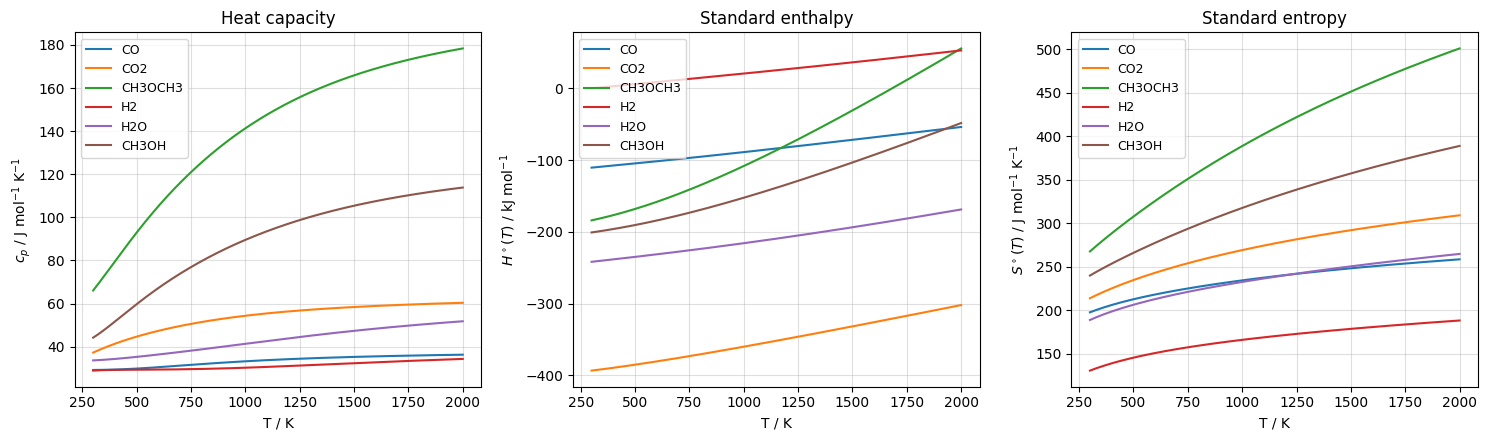

In [96]:
# Temperaturbereich
T_range = np.linspace(300, 2000, 1000)  # K, ggf. an deinen Gültigkeitsbereich anpassen
species_list = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']

# Daten sammeln
cp_data = np.full((len(species_list), len(T_range)), np.nan)
hf_data = np.full((len(species_list), len(T_range)), np.nan)
s_data  = np.full((len(species_list), len(T_range)), np.nan)

for i, sp in enumerate(species_list):
    for j, T in enumerate(T_range):
        try:
            cp_data[i, j] = cp_T(sp, T)
            hf_data[i, j] = hf_T(sp, T)
            s_data[i, j]  = s_T(sp, T)
        except ValueError:
            pass  # T außerhalb der NASA-Range → NaN bleibt

# Plot: 1×3 Layout
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, sp in enumerate(species_list):
    axes[0].plot(T_range, cp_data[i],        label=sp)
    axes[1].plot(T_range, hf_data[i] / 1000, label=sp)  # → kJ/mol
    axes[2].plot(T_range, s_data[i],         label=sp)

axes[0].set_xlabel('T / K')
axes[0].set_ylabel(r'$c_p$ / J mol$^{-1}$ K$^{-1}$')
axes[0].set_title('Heat capacity')

axes[1].set_xlabel('T / K')
axes[1].set_ylabel(r'$H^\circ(T)$ / kJ mol$^{-1}$')
axes[1].set_title('Standard enthalpy')

axes[2].set_xlabel('T / K')
axes[2].set_ylabel(r'$S^\circ(T)$ / J mol$^{-1}$ K$^{-1}$')
axes[2].set_title('Standard entropy')

for ax in axes:
    ax.grid(True, alpha=0.4)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

## Calculating Reaction-enthalpy, -entropy and -gibbs energy

In [97]:
def reaction_enthalpy(reaction, T):
    """
    Calculate the reaction enthalpy (ΔH) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔH: Reaction enthalpy in J/mol (float).
    """
    delta_H = 0.0
    for species, coeff in reaction:
        hf = hf_T(species, T)
        delta_H += coeff * hf
    return delta_H

def reaction_entropy(reaction, T):
    """
    Calculate the reaction entropy (ΔS) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔS: Reaction entropy in J/(mol*K) (float).
    """
    delta_S = 0.0
    for species, coeff in reaction:
        S = s_T(species, T)
        delta_S += coeff * S
    return delta_S

def reaction_gibbs_free_energy(reaction, T):
    """
    Calculate the reaction Gibbs free energy (ΔG) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔG: Reaction Gibbs free energy in J/mol (float).
    """
    delta_H = reaction_enthalpy(reaction, T)
    delta_S = reaction_entropy(reaction, T)
    delta_G = delta_H - T * delta_S
    return delta_G

def eq_const_p(reaction, T):
    """
    Calculate the equilibrium constant (K) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - K: Equilibrium constant (dimensionless).
    """
    delta_G = reaction_gibbs_free_energy(reaction, T)
    K = np.exp(-delta_G / (R * T))
    return K

# k_x = K_p * p^Δν

def stoich_coeff_change(reaction):
    """Change in molar stoichiometric coefficient Δν = Σ vi."""
    dnu = 0
    for species, coeff in reaction:
        dnu += coeff
    return dnu

def eq_const_x(reaction, T, p):
    """
    Calculate the equilibrium constant (K_x) at a given temperature T and pressure p for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    - p: Pressure in bar (float).
    
    Returns:
    - K_x: Equilibrium constant (dimensionless).
    """
    K_p = eq_const_p(reaction, T)
    dnu = stoich_coeff_change(reaction)
    K_x = K_p * (p ** (-dnu))
    return K_x

print('Gibbs')
print('R1:', reaction_gibbs_free_energy(reaction_tuples[0], 298.15))
print('R2:', reaction_gibbs_free_energy(reaction_tuples[1], 298.15))
print('R4:', reaction_gibbs_free_energy(reaction_tuples[2], 298.15))
print('R3:', reaction_gibbs_free_energy(reaction_tuples[3], 298.15))
print('----------------------------------')
print('Enthalpy')
print('R1:', reaction_enthalpy(reaction_tuples[0], 298.15))
print('R2:', reaction_enthalpy(reaction_tuples[1], 298.15))
print('R4:', reaction_enthalpy(reaction_tuples[2], 298.15))
print('R3:', reaction_enthalpy(reaction_tuples[3], 298.15))
print('----------------------------------')
print('Entropy')
print('R1:', reaction_entropy(reaction_tuples[0], 298.15))
print('R2:', reaction_entropy(reaction_tuples[1], 298.15))
print('R4:', reaction_entropy(reaction_tuples[2], 298.15))
print('R3:', reaction_entropy(reaction_tuples[3], 298.15))
print('----------------------------------')
print('Equilibrium Constant K_p')
print('R1:', eq_const_p(reaction_tuples[0], 298.15))
print('R2:', eq_const_p(reaction_tuples[1], 298.15))
print('R4:', eq_const_p(reaction_tuples[2], 298.15))
print('R3:', eq_const_p(reaction_tuples[3], 298.15))

Gibbs
R1: 3573.3371874515287
R2: -25045.293130465063
R4: -17075.091101065
R3: 28618.63031791654
----------------------------------
Enthalpy
R1: -49252.979123374535
R2: -90399.25909187923
R4: -24054.524918248877
R3: 41146.27996850465
----------------------------------
Entropy
R1: -177.18033309014277
R2: -219.19827590613505
R4: -23.40913572759979
R3: 42.01794281599231
----------------------------------
Equilibrium Constant K_p
R1: 0.2365612332455031
R2: 24433.72433787962
R4: 980.8283043707333
R3: 9.681750926475308e-06


## Visualizing the Values for $\Delta_{R}H(T)$, $\Delta_{R}S(T)$ and $\Delta_{R}G(T)$

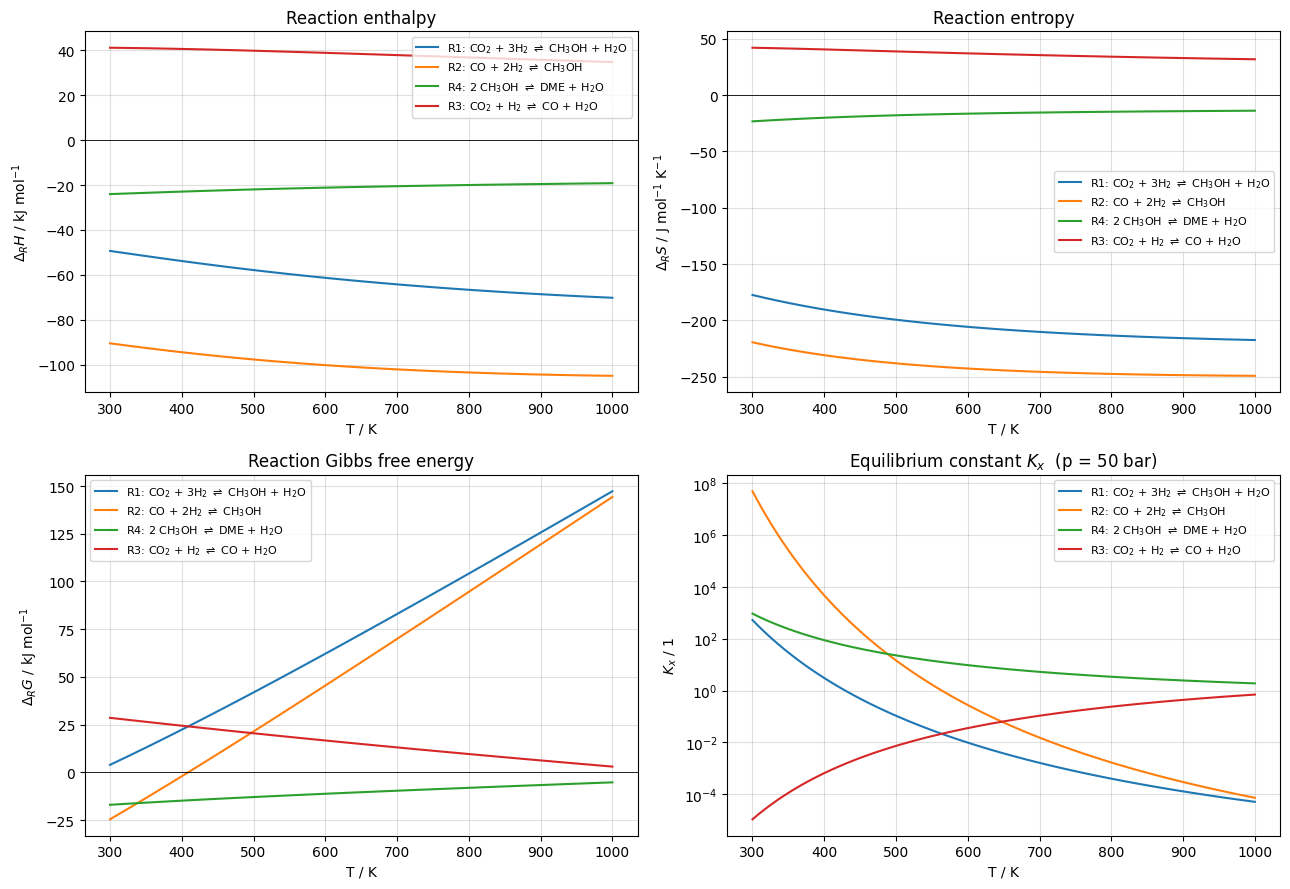

In [98]:
T_range = np.linspace(300, 1000, 100)

reaction_labels = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
    r'R4: 2 CH$_3$OH $\rightleftharpoons$ DME + H$_2$O',
    r'R3: CO$_2$ + H$_2$ $\rightleftharpoons$ CO + H$_2$O',
]

p_ref = 50  # bar — Referenzdruck für K_x (nur K_x ist druckabhängig)

# --- Daten berechnen ---
dH_data = np.full((4, len(T_range)), np.nan)
dS_data = np.full((4, len(T_range)), np.nan)
dG_data = np.full((4, len(T_range)), np.nan)
Kx_data = np.full((4, len(T_range)), np.nan)

for r_idx in range(4):
    for j, T in enumerate(T_range):
        try:
            dH_data[r_idx, j] = reaction_enthalpy(reaction_tuples[r_idx], T)
            dS_data[r_idx, j] = reaction_entropy(reaction_tuples[r_idx], T)
            dG_data[r_idx, j] = reaction_gibbs_free_energy(reaction_tuples[r_idx], T)
            Kx_data[r_idx, j] = eq_const_x(reaction_tuples[r_idx], T, p_ref)
        except ValueError:
            pass

# --- 2×2 Plot ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()  # [ΔH, ΔS, ΔG, K_x]

for r_idx in range(4):
    axes[0].plot(T_range, dH_data[r_idx] / 1000, label=reaction_labels[r_idx])
    axes[1].plot(T_range, dS_data[r_idx],         label=reaction_labels[r_idx])
    axes[2].plot(T_range, dG_data[r_idx] / 1000,  label=reaction_labels[r_idx])
    axes[3].plot(T_range, Kx_data[r_idx],          label=reaction_labels[r_idx])

axes[0].set_ylabel(r'$\Delta_R H$ / kJ mol$^{-1}$')
axes[0].set_title('Reaction enthalpy')

axes[1].set_ylabel(r'$\Delta_R S$ / J mol$^{-1}$ K$^{-1}$')
axes[1].set_title('Reaction entropy')

axes[2].set_ylabel(r'$\Delta_R G$ / kJ mol$^{-1}$')
axes[2].set_title('Reaction Gibbs free energy')

axes[3].set_ylabel(r'$K_x$ / 1')
axes[3].set_title(f'Equilibrium constant $K_x$  (p = {p_ref} bar)')
axes[3].set_yscale('log')  # log-Skala wegen der Größenordnungen (R2 >> R3)

for ax in axes:
    ax.set_xlabel('T / K')
    ax.grid(True, alpha=0.4, which='both')
    ax.axhline(0, color='k', lw=0.6)
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

## Getting $\xi$ from $K_x$

Above, we have calculated $K_x$, wich is for a single reaction defined as:

\begin{align}
    K_x &= \prod_i x_i^{\nu_i}
\end{align}

Our goal is, to calculate the reaction extend $\xi_i$ for all reaction j = {1,2,3,4}. This is done as follows:

The mass balance of component i in a reaction network, like the given one here, is:

\begin{align}
    \dot{n_{i,out}} &= \dot{n_{i,in}} + \sum_{j=1}^N \nu_{i,j} \cdot \xi_{j}
\end{align}

Therefor

\begin{align}
    \dot{n_{out}} &= \dot{n_{in}} + \sum_{j=1}^N \xi_{j} \cdot (\sum_i^M \nu_{j, i})
\end{align}

From this, we can write the molar fraction of species i as

\begin{align}
  x_{i,out} &= \frac{\dot n_{i,out}}{\dot n_{out}}=\frac{\dot{n_{i,in}} + \sum_{j=1}^N \nu_{i,j} \cdot \xi_{j}}{\dot{n_{in}} + \sum_{j=1}^N \xi_{j} \cdot (\sum_i^M \nu_{j, i})}
\end{align}

With this equation, we can calculate $x_i$ for an initual guess of $\xi$. Then we iteratively solve for the root of the equation

\begin{align}
    K_{j,i} - \prod_i x_{j,i}^{\nu_i} = 0
\end{align}

for our three Key reactions specified above. This gives us a numerical solution for the reaction extend $\xi$.

In [99]:
from scipy.optimize import root

def material_balance(reaction, xi, n_in, rc_ind):
    """
    Calculate the material balance for a given reaction, extent of reaction (xi), and initial moles (n_in).
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - xi: Extent of reactions (array of floats).
    - n_in: Initial moles of each species as an array [mol/h].
    - rc_ind: Indexes of the reactions for which to solve. (array of ints)
    
    Returns:
    - n_out: Final moles of each species after the reaction as an array [mol/h].
    """
    n_out = n_in.copy()                                     # Start with initial moles
    for i in range(min(len(rc_ind), len(reaction))):        # Loop through the reactions up to the specified index
        for j in range(len(n_in)):                          # Calculate the change in moles for each species based on the reaction coefficients and extent of reaction
            species, coeff = reaction[rc_ind[i]][j]
            n_out[j] = n_out[j] + (coeff * xi[i])           # Update the moles based on the extent of reaction and the stoichiometric coefficients
    return n_out                                            # Return the final moles after the reaction for the solver to compare and refine the guess of xi

def mole_fraction(n_out):
    """
    Calculate the mole fraction of each species given the final moles.
    
    Parameters:
    - n_out: Final moles of each species as an array [mol/h].
    
    Returns:
    - x: Mole fraction of each species as an array.
    """
    total_moles = np.sum(n_out)
    if total_moles == 0:
        return np.zeros_like(n_out)  # Avoid division by zero
    x = n_out / total_moles
    return x

from scipy.optimize import least_squares

def equilibrium_residuals(xi, reaction_list, n_in, T, p, reac_index, penalty_weight=1e4):
    """
    Residuen der Gleichgewichtsbedingungen plus Strafterm für unphysikalische Mengen.
    
    Parameters
    ----------
    xi : array, shape (n_reactions,)
        Reaktionslaufzahlen.
    reaction_list : list
        Liste aller Reaktionen (Tupel-Form).
    n_in : array, shape (n_species,)
        Eingangsstoffmengen.
    T, p : float
        Temperatur [K], Druck [bar].
    reac_index : array of int
        Indizes der Schlüsselreaktionen in reaction_list.
    penalty_weight : float
        Stärke, mit der der Solver aus unphysikalischen Regionen "geschoben" wird.
    """
    # 1) Coupled material balance: Calculate the output moles based on the current guess of xi and the initial moles. 
    # This is done by applying the stoichiometric changes from each reaction to the initial moles, resulting in the final moles after the reactions have occurred according to the current extent of reaction (xi). 
    # The material balance function takes into account all specified reactions and their respective extents to compute the resulting moles of each species, which are then used to calculate mole fractions and equilibrium residuals.
    n_out = material_balance(reaction_list, xi, n_in, reac_index)
    
    # 2) catching negative moles with a penalty (quadratic, only for negative values). This is added to the residuals to push the solver back into the physically meaningful region where all moles are non-negative.
    neg_violation = np.minimum(n_out, 0.0)          # 0 if ≥0, otherwise the negative value (violation)
    penalty = penalty_weight * np.sum(neg_violation**2)

    # 3) Numerically stable mole fractions (clipping protects against 0**(-n) and n<0)
    n_out_safe = np.maximum(n_out, 1e-15)
    x = n_out_safe / np.sum(n_out_safe)
    
    # 4) Equilibrium residuals, reaction-agnostic via sign of coefficients
    res = np.zeros(len(reac_index))
    for k, j in enumerate(reac_index):
        K_x = eq_const_x(reaction_list[j], T, p)
        educt_term   = 1.0
        product_term = 1.0
        for i, (species, coeff) in enumerate(reaction_list[j]):
            if coeff < 0:        # Edukt
                educt_term   *= x[i] ** abs(coeff)
            elif coeff > 0:      # Produkt
                product_term *= x[i] ** coeff
        res[k] = K_x * educt_term - product_term
    
    # 5) Incorporate the penalty into all residuals (pushes the solver back into the feasible region)
    return res + penalty


def root_solver_bounded(reaction_list, xi_init, n_in, T, p, reac_index, penalty_weight=1e4):
    """
    Beschränkte Lösung für gekoppelte Reaktionsgleichgewichte via least_squares.
    
    Returns
    -------
    xi : array
        Optimale Reaktionslaufzahlen.
    sol : OptimizeResult
        Volles Solver-Objekt (für Diagnose: sol.success, sol.message, sol.cost).
    """
    # Defining bounds for xi based on the initial moles and the stoichiometry of the reactions to ensure that the solver does not explore unphysical regions where the output moles would become negative. 
    # The bounds are set symmetrically around zero, allowing for both forward and reverse reactions, but are limited by the total available moles to prevent excessive extents that would lead to negative concentrations.
    n_total = max(np.sum(n_in), 1.0)
    lower = -n_total * np.ones(len(reac_index))
    upper =  n_total * np.ones(len(reac_index))
    
    # Projecting the starting guesses for xi into the feasible region defined by the bounds to ensure the solver starts with a valid point.
    xi_init = np.clip(np.asarray(xi_init, dtype=float), lower + 1e-9, upper - 1e-9)
    
    sol = least_squares(
        equilibrium_residuals,
        xi_init,
        args=(reaction_list, n_in, T, p, reac_index, penalty_weight),
        bounds=(lower, upper),
        method='trf',
    )
    return sol.x, sol


# --- Testcases---
for k, n_in_test in enumerate([
    np.array([1.0, 1.0, 0.0, 2.0, 0.0, 0.0]),
    np.array([2.0, 1.0, 1.0, 0.0, 2.0, 1.0]),
    np.array([0.0, 0.0, 0.0, 2.0, 1.0, 2.0]),
    np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0]),
    np.array([2.0, 1.0, 0.0, 1.0, 0.0, 0.0]),
]):
    xi, sol = root_solver_bounded(reaction_tuples, [0.01, 0.01, 0.01], n_in_test, 500, 1, [0, 1, 2])
    n_out = material_balance(reaction_tuples, xi, n_in_test, [0, 1, 2])
    print(f"Test {k+1}: xi = {xi}, success = {sol.success}, n_out ≥ 0: {np.all(n_out >= -1e-9)}")


Test 1: xi = [0.00785904 0.00126873 0.00385095], success = True, n_out ≥ 0: True
Test 2: xi = [ 1.00008482 -3.98119158 -0.99356571], success = True, n_out ≥ 0: False
Test 3: xi = [-1.07973868 -0.75385223  0.08187762], success = True, n_out ≥ 0: True
Test 4: xi = [-0.86438885 -0.40441516 -0.1354865 ], success = True, n_out ≥ 0: True
Test 5: xi = [-0.00037908  0.00852977  0.00372235], success = True, n_out ≥ 0: True


# Visualizing the reaction etxend $\xi$ as a function of T, p and inlet concentration

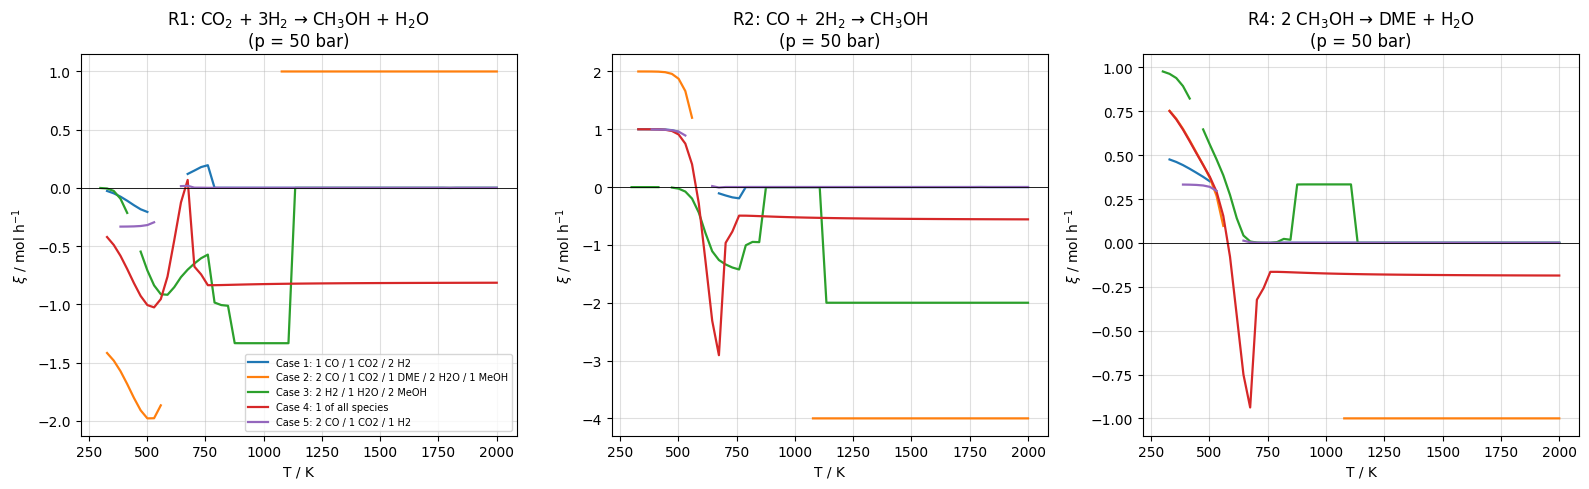

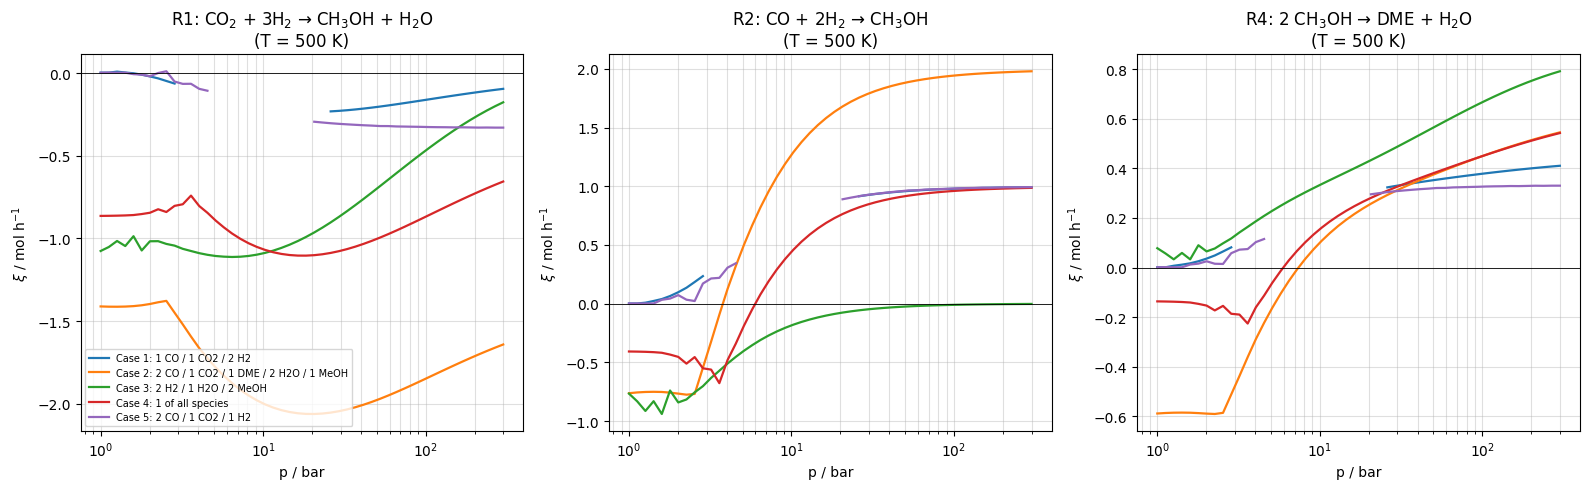

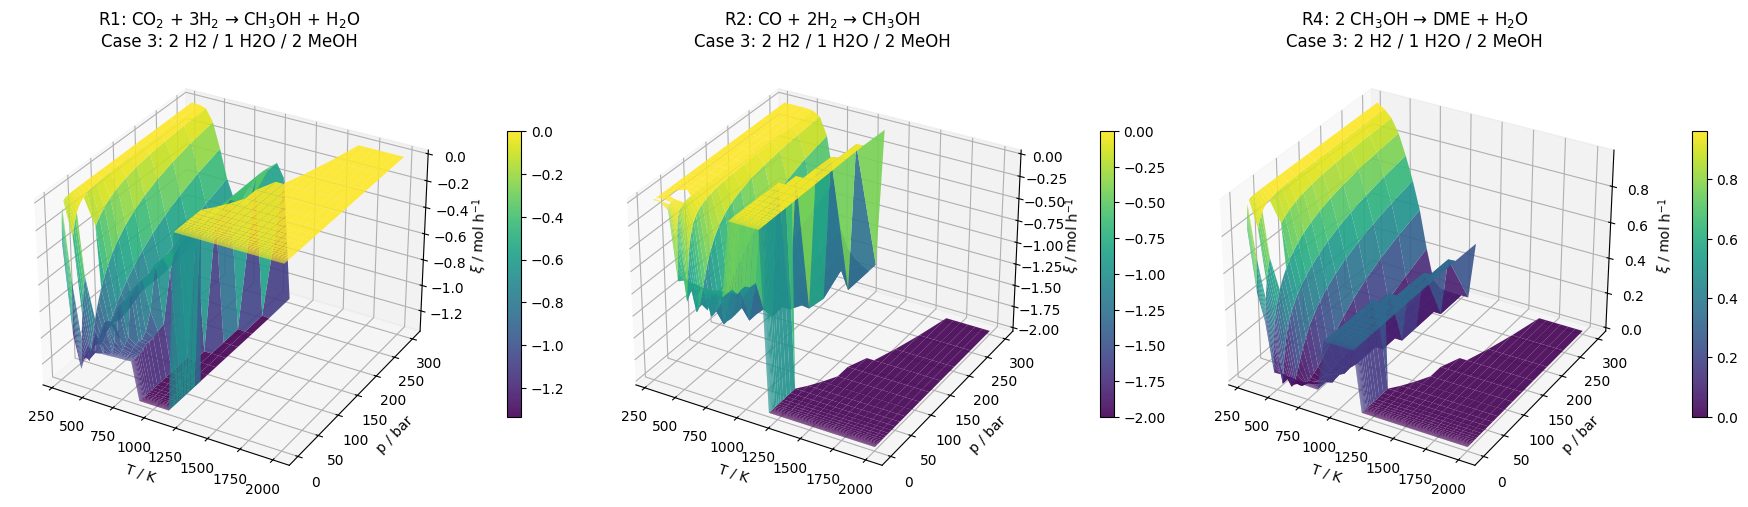

In [103]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (3D-Backend aktivieren)

# --- Testfälle ---
test_cases = [
    ("Case 1: 1 CO / 1 CO2 / 2 H2",           np.array([1.0, 1.0, 0.0, 2.0, 0.0, 0.0])),
    ("Case 2: 2 CO / 1 CO2 / 1 DME / 2 H2O / 1 MeOH", np.array([2.0, 1.0, 1.0, 0.0, 2.0, 1.0])),
    ("Case 3: 2 H2 / 1 H2O / 2 MeOH",         np.array([0.0, 0.0, 0.0, 2.0, 1.0, 2.0])),
    ("Case 4: 1 of all species",              np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])),
    ("Case 5: 2 CO / 1 CO2 / 1 H2",           np.array([2.0, 1.0, 0.0, 1.0, 0.0, 0.0])),
]

reaction_indices       = [0, 1, 2]                                # R1, R2, R4
reaction_labels_short  = ['R1: CO$_2$ + 3H$_2$ → CH$_3$OH + H$_2$O',
                          'R2: CO + 2H$_2$ → CH$_3$OH',
                          'R4: 2 CH$_3$OH → DME + H$_2$O']

# --- Sichere Solver-Wrapper-Funktion ---
def safe_solve(n_in, T, p, xi_init=(0.001, 0.001, 0.001)):
    """
    Robust wrapper: returns xi or NaN-array on failure / unphysical result.
    """
    try:
        xi, sol = root_solver_bounded(reaction_tuples, list(xi_init),
                                       n_in, T, p, reaction_indices)
        if not sol.success:
            return np.full(3, np.nan)
        n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
        tol = 1e-6 * max(np.sum(n_in), 1.0)
        if np.any(n_out < -tol):
            return np.full(3, np.nan)
        return xi
    except Exception:
        return np.full(3, np.nan)

# ====================== ξ vs T (bei festem p) ======================
T_range  = np.linspace(300, 2000, 60)
p_fixed  = 50  # bar — Mittelfeld

xi_T = np.full((len(test_cases), 3, len(T_range)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    for ti, T in enumerate(T_range):
        xi_T[ci, :, ti] = safe_solve(n_in, T, p_fixed)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for r_idx in range(3):
    for ci, (name, n_in) in enumerate(test_cases):
        axes[r_idx].plot(T_range, xi_T[ci, r_idx, :], label=name, lw=1.6)
    axes[r_idx].set_xlabel('T / K')
    axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
    axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(p = {p_fixed} bar)')
    axes[r_idx].grid(True, alpha=0.4)
    axes[r_idx].axhline(0, color='k', lw=0.6)
axes[0].legend(loc='best', fontsize=7)
plt.tight_layout()
plt.show()


# ====================== ξ vs p (bei festem T) ======================
p_range  = np.logspace(0, np.log10(300), 50)  # 1 ... 300 bar, log-skaliert
T_fixed  = 500  # K — typisch für DME-Synthese

xi_p = np.full((len(test_cases), 3, len(p_range)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    for pi, p in enumerate(p_range):
        xi_p[ci, :, pi] = safe_solve(n_in, T_fixed, p)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for r_idx in range(3):
    for ci, (name, n_in) in enumerate(test_cases):
        axes[r_idx].plot(p_range, xi_p[ci, r_idx, :], label=name, lw=1.6)
    axes[r_idx].set_xlabel('p / bar')
    axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
    axes[r_idx].set_xscale('log')
    axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(T = {T_fixed} K)')
    axes[r_idx].grid(True, alpha=0.4, which='both')
    axes[r_idx].axhline(0, color='k', lw=0.6)
axes[0].legend(loc='best', fontsize=7)
plt.tight_layout()
plt.show()


# ====================== 3D-Surface: ξ(T,p) für einen Testfall ======================
SELECTED_CASE = 2   # ← Index 0..4, hier z.B. Case 1

name, n_in = test_cases[SELECTED_CASE]

# Grid (gröber als bei den 2D-Plots, damit es nicht zu lange dauert)
T_3d = np.linspace(300, 2000, 30)
p_3d = np.logspace(0, np.log10(300), 30)
T_mesh, p_mesh = np.meshgrid(T_3d, p_3d)

xi_TP = np.full((3, len(p_3d), len(T_3d)), np.nan)

for ti, T in enumerate(T_3d):
    for pi, p in enumerate(p_3d):
        xi_TP[:, pi, ti] = safe_solve(n_in, T, p)

fig = plt.figure(figsize=(18, 5.5))
for r_idx in range(3):
    ax = fig.add_subplot(1, 3, r_idx + 1, projection='3d')
    surf = ax.plot_surface(
        T_mesh, p_mesh, xi_TP[r_idx],
        cmap='viridis', alpha=0.9, edgecolor='none'
    )
    ax.set_xlabel('T / K')
    ax.set_ylabel('p / bar')
    ax.set_zlabel(r'$\xi$ / mol h$^{-1}$')
    ax.set_title(f'{reaction_labels_short[r_idx]}\n{name}')
    fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.1)

plt.tight_layout()
plt.show()

# ToDo's for Tomorrow:

- Validating of the plots and getting to know them
- Plotting the reaction extend
- commenting all of the code
- Translating all german comments into english

# Graveyard of Code

In [101]:

# def root_solver(reaction_list, xi_init, n_in, T, p, reac_index):
#     """
#     Wrapper function for root solver to find the extent of reaction (xi) that satisfies the equilibrium condition.
    
#     Parameters:
#     - reaction_list: A list of lists of tuples representing the reactions. Each tuple contains (species, coefficient). Coefficients should be negative for reactants and positive for products.
#     - xi_init: Initial guesses for the extent of reaction (array of floats).
#     - n_in: Initial moles of each species as an array [mol/h]. MUST have the same order as the species in the reaction dictionary for all reactions R1-R4 (Co, CO2, CH3OCH3, H2, H2O, CH3OH) . MUST be initialized as a float array, else the function will not work properly. (array of floats)
#     - T: Temperature in Kelvin (float).
#     - p: Pressure in bar (float).
#     - reac_index: Indexes of the reactions for which to solve (array of int). R1 = 0, R2 = 1, R4 = 2, R3 = 3.
#     Returns:
#     - xi_solution: Extent of reaction that satisfies the equilibrium condition (float).
#     """
#     def equilibrium_condition(xi):

#         res = np.array([])               # Storage List for results of each reaction
#         n_out = material_balance(reaction_list, xi, n_in, reac_index)  # Get the final moles after the reaction based on the current guess of xi
#         x = mole_fraction(n_out)
#         K_x_1 = eq_const_x(reaction_list[0], T, p)
#         K_x_2 = eq_const_x(reaction_list[1], T, p)
#         K_x_3 = eq_const_x(reaction_list[2], T, p)
#         K_x_4 = eq_const_x(reaction_list[3], T, p)
#         for j in range(len(reac_index)):
#             stoich_coeff_storage = []
#             for i in range(len(reaction_list[j])):
#                 species, coeff = reaction_list[j][i]
#                 stoich_coeff_storage.append(abs(float(coeff)))

#             if reac_index[j] == 0:
#                 res1 = K_x_1 * (x[1]**stoich_coeff_storage[1]) * (x[3]**stoich_coeff_storage[3]) - (x[5]**stoich_coeff_storage[5]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res1)
#             elif reac_index[j] == 1:
#                 res2 = K_x_2 * (x[0]**stoich_coeff_storage[0]) * (x[3]**stoich_coeff_storage[3]) - (x[5]**stoich_coeff_storage[5])
#                 res = np.append(res, res2)
#             elif reac_index[j] == 3:
#                 res3 = K_x_3 * (x[1]**stoich_coeff_storage[1]) * (x[3]**stoich_coeff_storage[3]) - (x[0]**stoich_coeff_storage[0]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res3)
#             elif reac_index[j] == 2:
#                 res4 = K_x_4 * (x[5]**stoich_coeff_storage[5]) - (x[2]**stoich_coeff_storage[2]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res4)

#         return res
#     solution = root(equilibrium_condition, xi_init,method='hybr')
#     return solution.x

# def root_solver_wrapper(reaction_list, xi_init, n_in, T, p, reac_index):
#     """
#     Wrapper function for root solver to find the extent of reaction (xi) that satisfies the equilibrium condition for a list of reactions.
    
#     Parameters:
#     - reaction_list: A list of reactions, where each reaction is a list of tuples representing the reaction. Each tuple contains (species, coefficient). Coefficients should be negative for reactants and positive for products.
#     - xi_init: Initial guess for the extent of reaction (array).
#     - n_in: Initial moles of each species as an array [mol/h]. MUST have the same order as the species in the reaction dictionary for all reactions R1-R4.
#     - T: Temperature in Kelvin (float).
#     - p: Pressure in bar (float).
#     - reac_index: Index of the reaction for which to solve (int). R1 = 0, R2 = 1, R3 = 2, R4 = 3.
    
#     Returns:
#     - xi_solutions: A list of extents of reaction that satisfy the equilibrium condition for each reaction in the list.
#     """
#     xi_solutions = []
#     for i in range(len(reaction_list)):
#         xi_solution = root_solver(reaction_list[i], xi_init, n_in, T, p, reac_index)
#         xi_solutions.append(xi_solution)
#     return xi_solutions


# print(reaction_tuples[0])
